In [3]:
import pickle
from pathlib import Path
from functools import partial
import copy
import random as pyrandom
import os

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import cmasher as cmr

import jax.numpy as jnp

from embers_passes import make_knots_from_grid, make_disk_mask, make_flat_index, \
    eval_spline_batch, make_constraint_info, scatter_coeffs, \
        SphericalSpline, eval_spline_samples, PassFile, bin_chunk, healpix_to_pyuvdata, \
        chunk_passes, get_above_horizon, prep_mwa_beam, get_pol_ind, fill_map, get_res

import arviz as az

import jax
import numpyro.distributions as dist

import healpy as hp

import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})

In [4]:
def prep_spline_params(beam, ortho_knots=False, spice_variant=0):
    if ortho_knots:
        if spice_variant:
            if spice_variant > 3: # Increasing density only at horizon
                interval_1 = np.arange(-1, -0.6, 0.05 / (2**(spice_variant - 3)))
                interval_2 = np.arange(-0.6, -0.4, 0.025)
                interval_3 = np.arange(-0.4, 0., 0.1)
            elif spice_variant == 3: # Twice as dense except in main lobe
                interval_1 = np.arange(-1., -0.6, 0.025)
                interval_2 = np.arange(-0.6, -0.4, 0.0125)
                interval_3 = np.arange(-0.4, 0., 0.1)
            elif spice_variant == 2: # Twice as dense except at horizon
                interval_1 = np.arange(-1., -0.6, 0.05)
                interval_2 = np.arange(-0.6, -0.4, 0.0125)
                interval_3 = np.arange(-0.4, 0., 0.05)
            else: # Twice as dense everywhere
                interval_1 = np.arange(-1., -0.6, 0.025)
                interval_2 = np.arange(-0.6, -0.4, 0.0125)
                interval_3 = np.arange(-0.4, 0., 0.05)
        else:
            interval_1 = np.arange(-1., -0.6, 0.05)
            interval_2 = np.arange(-0.6, -0.4, 0.025)
            interval_3 = np.arange(-0.4, 0., 0.1)

        base_knots = np.concatenate([
            interval_1, 
            interval_2, 
            interval_3,
            np.atleast_1d([0.]),
            -np.flip(interval_3),
            -np.flip(interval_2),
            -np.flip(interval_1)
        ])

        t_x, t_y, p, q, n_x, n_y = make_knots_from_grid(base_knots, base_knots)
        Nparam = n_x * n_y

        return t_x, t_y, p, q, n_x, n_y, Nparam
    else:
        theta_param = beam.axis2_array[1::10] # avoid the origin by a quarter degree
        phi_param = beam.axis1_array[::10]

        # ONCE, outside the model:
        t_theta, t_phi, p, q, n_th, n_ph = make_knots_from_grid(theta_param, phi_param)
        Nparam = n_th * n_ph
        return t_theta, t_phi, p, q, n_th, n_ph, Nparam




Set passdir according to where raw data are kept

In [5]:
passdir = "/path/to/passes"
rf_num = 0
tile = "06"
pol = "XX"


path = Path(f"{passdir}/rf{rf_num}/S{tile}{pol}_rf{rf_num}{pol}_passes.h5")
pf = PassFile(path)
# Only 0 pointing
passes = pf.read_passes(pointing=0)
Npass_total = len(passes)
print(Npass_total)

jackknife = False
jackknife_mode = "time"
jackknife_chunk = 3
num_pass = None
chunk_sec = 20 * 86400

if jackknife:
    if jackknife_mode == "random": # shuffle the passes first
        pyrandom.seed(args.jackknife_key)
        pyrandom.shuffle(passes)
        if jackknife_chunk: # implicitly second half
            chunk = list(range(Npass_total // 2, Npass_total))
        else: # otherwise first half
            chunk = list(range(Npass_total // 2))
    elif jackknife_mode == "time":
        chunks, bins_edges, bin_centers = chunk_passes(passes, chunk_sec)
        chunk = chunks[jackknife_chunk]
    else:
        raise ValueError("Invalid jackknife mode. Should be 'time' or 'random'. Check config file." )
elif num_pass is None:
    chunk = list(range(Npass_total))
else:
    chunk = list(range(num_pass))


median_map, count_map, mad_map, median_sem_map = bin_chunk(
    passes, chunk
)
median_values, za_rad, az_rad = healpix_to_pyuvdata(median_map)
count_values, _, _ = healpix_to_pyuvdata(count_map)
mad_values, _, _ = healpix_to_pyuvdata(mad_map)
median_sem_values, _, _ = healpix_to_pyuvdata(median_sem_map)

count_gt_2 = count_values > 2 # MAD estimates completely untrustworthy for counts less than 3
median_values = median_values[count_gt_2]
za_rad = za_rad[count_gt_2]
az_rad = az_rad[count_gt_2]
mad_values = mad_values[count_gt_2]
count_values = count_values[count_gt_2]
median_sem_values = median_sem_values[count_gt_2]

1759


In [5]:
DEBUG_POL = False

mwa_beamfile = "/path/to/mwa/beamfile"

beam = prep_mwa_beam(mwa_beamfile)
pol_ind = get_pol_ind(beam, pol)

if DEBUG_POL:   
    pol_ind = 1 - pol_ind


Only one available frequency in freq_range.


In [6]:
t_x, t_y, p, q, n_x, n_y, _= prep_spline_params(beam, ortho_knots=True)
knot_mask = make_disk_mask(t_x, t_y, p, q)           # (n_x, n_y) bool, numpy
knot_ij, Nparam = make_flat_index(knot_mask)            # static arrays


(
    pivot_flat_idx, pivot_weight, contrib_flat_idxs, contrib_weights
) = make_constraint_info(
    t_x, t_y, p, q, u0=0, v0=0, ij=knot_ij # FIXME: Hardcode zenith-pointed
)
dat_coord_1 = jnp.sin(za_rad) * jnp.cos(az_rad)
dat_coord_2 = jnp.sin(za_rad) * jnp.sin(az_rad)

Set paper_plot_dir according to system (plots go here)

The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.


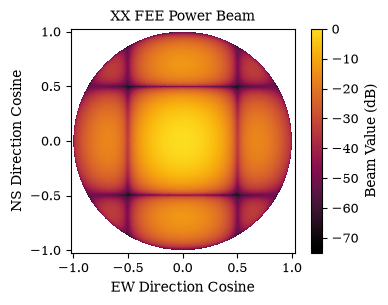

In [ ]:
paper_plot_dir = f"/path/to/plotdir/rf{rf_num}/S{tile}/{pol}"
make_plot_dir = False
if not os.path.exists(paper_plot_dir) and make_plot_dir:
    os.makedirs(paper_plot_dir)

SAVE_FEE_BEAM_PLOT = True
with_knots = True
axis_limit = 1.025

def to_db(lin):
    return 10 * np.log10(lin)


rbeam = np.sin(beam.axis2_array)
xbeam = rbeam[:, None] * np.cos(beam.axis1_array)[None, :]
ybeam = rbeam[:, None] * np.sin(beam.axis1_array)[None, :]

fig, ax = plt.subplots(figsize=(4.2, 4.2 * 0.75))

ax.set_aspect("equal")
ax.set_xlabel("EW Direction Cosine")
ax.set_ylabel("NS Direction Cosine")
ax.set_title(f"{pol} FEE Power Beam")

wildfire_top = cmr.get_sub_cmap(cmr.wildfire, 0.5, 1).with_extremes(under="white")

im = ax.pcolormesh(
    xbeam, 
    ybeam, 
    to_db(beam.data_array[0, pol_ind, 0].real), 
    cmap=wildfire_top,
    vmax=0,
    rasterized=True
)

if with_knots:
    dp = (p + 1) // 2
    dq = (q + 1) // 2
    T_x, T_y = np.meshgrid(t_x[dp:-dp], t_y[dq:-dq], indexing="ij")
    ax.scatter(T_x[knot_mask], T_y[knot_mask], marker="s", s=0.5, alpha=0.75, 
            color="#2eb09e")
fig.colorbar(im, ax=ax, label="Beam Value (dB)")


ax.set_xlim([-axis_limit, axis_limit])
ax.set_ylim([-axis_limit, axis_limit])
fig.tight_layout()


if SAVE_FEE_BEAM_PLOT:
    fig.savefig(
        f"{paper_plot_dir}/FEE_with_knots_{with_knots}.pdf",
        bbox_inches="tight"
    )


Set indir to where MCMC samples are kept

In [8]:
indir = f"/mcmc/out/dir/rf{rf_num}/S{tile}/{pol}"
if jackknife:
    indir = f"{indir}/{jackknife_mode}_jackknife/chunk{jackknife_chunk}"
print(indir)

svi = False
if svi:
    params_filepath = f"{indir}/svi_laplace_samps.pkl"

    with open(params_filepath, "rb") as params_file:
        params = pickle.load(params_file)
else:
    coeffs = az.from_netcdf(f"{indir}/mcmc_out.nc")

/Users/mwilensky/projects/satellite_beams/test_outputs/rawish_test/rf0/S06/XX


In [9]:
res, model_beam = get_res(az_rad, za_rad, median_values, pol_ind, beam)

In [10]:
if svi:
    coeffs_to_use = params["surf_vals"].mean(axis=0)
else:
    coeffs_to_use = jnp.array(coeffs.posterior["surf_vals"]).reshape(16000, -1).mean(axis=0)
print(coeffs_to_use.shape)
coeffs_to_use = scatter_coeffs(
    coeffs_to_use,
    knot_mask, 
    knot_ij
)
print(coeffs_to_use.shape)
spl = SphericalSpline(t_x, t_y, coeffs_to_use, p, q)


(1473,)
(41, 41)


In [11]:
class SkewLogistic(dist.Distribution, metaclass=dist.distribution.DistributionMeta):
    """
    Type I Generlized Logistic Distribution.
    """
    arg_constraints = {
        "loc": dist.constraints.real,
        "scale": dist.constraints.positive,
        "shape": dist.constraints.positive
    }
    support = dist.constraints.real
    has_rsample = False

    def __init__(self, loc=0., scale=1., shape=1., *, validate_args=None):
        self.loc = loc
        self.scale = scale
        self.shape = shape
        

        batch_shape = jax.lax.broadcast_shapes(
            jnp.shape(loc),
            jnp.shape(scale),
            jnp.shape(shape),
        )
        super(SkewLogistic, self).__init__(batch_shape=batch_shape, validate_args=validate_args)

    def __new__(cls, *args, **kwargs):
        return object.__new__(cls)

    def log_prob(self, x):
        centered = (x - self.loc) / self.scale
        return -jnp.log(self.scale) + jnp.log(self.shape) - centered - (self.shape + 1) * jnp.log1p(jnp.exp(-centered))

    def sample(self, key, sample_shape=()):
        final_sample_shape = self.batch_shape + sample_shape
        beta_samp = random.beta(key, self.shape, jnp.ones_like(self.shape), shape=final_sample_shape)
        centered_samp = jnp.log(beta_samp / (1 - beta_samp))
        return self.scale * centered_samp + self.loc

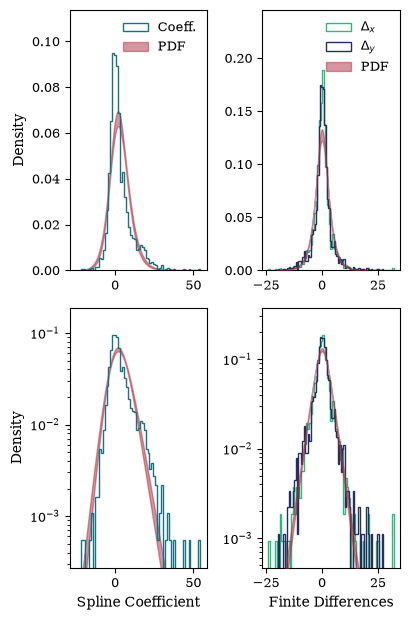

In [12]:
coeff_hist_kwargs = {"bins": "auto", "histtype": "step", "density": True}

xplot_coeff = np.linspace(-25, 55, num=1000)
skew_log = SkewLogistic(
    loc=0, 
    scale=jnp.array(coeffs.posterior["scale_vals"].values.flatten()[:, None]), 
    shape=jnp.array(coeffs.posterior["shape_vals"].values.flatten()[:, None])
)
skew_log_prob = jnp.exp(skew_log.log_prob(xplot_coeff[None, :]))
slp_mean = skew_log_prob.mean(axis=0)
slp_std = skew_log_prob.std(axis=0)

fig, ax = plt.subplots(figsize=(4.2, 6.3), ncols=2, nrows=2)
lin_ax, log_ax = ax

coeffs_to_hist = coeffs_to_use[knot_mask].flatten()
grads_to_hist = [jnp.gradient(coeffs_to_use)[k][knot_mask].flatten() for k in range(2)]

grad_laplace = dist.SoftLaplace(
    loc=0,
    scale=jnp.array(coeffs.posterior["scale_grad"].values.flatten()[:, None])
)
xplot_grad = np.linspace(-20, 20, num=1000)
grad_laplace_prob = jnp.exp(grad_laplace.log_prob(xplot_grad[None, :]))

std_mult = 5

for ax_ind, ax_ob in enumerate([lin_ax[0], log_ax[0]]):
    # Histogram of coefficients
    counts, _, _ = ax_ob.hist(
        coeffs_to_hist,
        color=cmr.wildfire(0.25),
        label="Coeff.",
        **coeff_hist_kwargs

    )

    # +/- 1 std shaded region
    ax_ob.fill_between(
        xplot_coeff,
        slp_mean - 2 * slp_std,
        slp_mean + 2 * slp_std,
        color=cmr.wildfire(0.75),
        alpha=0.5,
        label="PDF",
    )
    ax_ob.set_ylabel("Density")
    
    if ax_ind:
        ax_ob.set_yscale("log")
        ax_ob.set_ylim([0.5 * np.amin(counts[counts > 0]), 2 * np.amax(counts)])
        ax_ob.set_xlabel("Spline Coefficient")
    else:
        ax_ob.set_yscale("linear")
        ax_ob.set_ylim([0, 1.2 * np.amax(counts)])

grad_labels = ["x", "y"]
for ax_ind, ax_ob in enumerate([lin_ax[1], log_ax[1]]):
    # Histogram of both gradient-related quantities
    counts_list = []
    for grad_ind, grad_arr in enumerate(grads_to_hist):
        counts, _, _ = ax_ob.hist(
            grad_arr,
            color=cmr.wildfire(0.125 + 0.25 * grad_ind),
            label=rf"$\Delta_{grad_labels[grad_ind]}$",
            **coeff_hist_kwargs
        )
        counts_list.append(counts)

    # +/- 1 std shaded region
    ax_ob.fill_between(
        xplot_grad,
        grad_laplace_prob.mean(axis=0) - 2 * grad_laplace_prob.std(axis=0),
        grad_laplace_prob.mean(axis=0) + 2 * grad_laplace_prob.std(axis=0),
        color=cmr.wildfire(0.75),
        alpha=0.5,
        label="PDF",
        zorder=3
    )

    all_counts = np.concatenate(counts_list)
    if ax_ind:
        ax_ob.set_yscale("log")
        ax_ob.set_ylim([0.5 * np.amin(all_counts[all_counts > 0]), 2 * np.amax(all_counts)])
        ax_ob.set_xlabel("Finite Differences")
    else:
        ax_ob.set_yscale("linear")
        ax_ob.set_ylim([0, 1.3 * np.amax(all_counts)])
ax[0,0].legend(frameon=False)
ax[0, 1].legend(frameon=False)
fig.tight_layout()
fig.savefig(f"{paper_plot_dir}/hierarchical_hist.pdf")

In [13]:
mod_for_data = eval_spline_batch(spl, dat_coord_1, dat_coord_2)
errors = res - mod_for_data


(-5.0, 5.0)

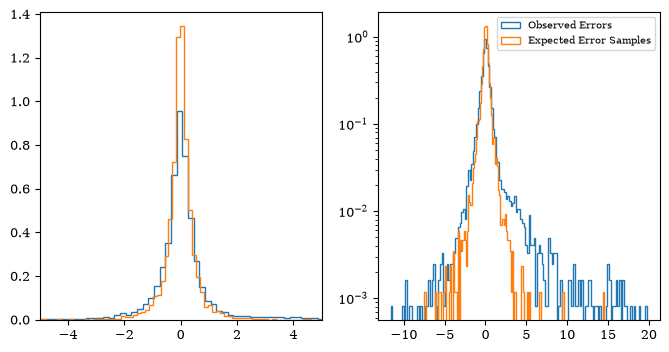

In [14]:
noise_scale = np.sqrt(mad_values**2 + median_sem_values**2)
sl = dist.SoftLaplace(
    loc=0, 
    scale=noise_scale * 2 / jnp.pi
)
sl_samps = sl.sample(jax.random.key(23674671))

fig, ax = plt.subplots(figsize=(8, 4), ncols=2)
hist_kwargs = {"bins": "auto", "histtype": "step", "density": True}

za_cutoff = 90.

for ax_ob in ax:
    ax_ob.hist(errors[za_rad < np.deg2rad(za_cutoff)], label="Observed Errors", **hist_kwargs)
    ax_ob.hist(sl_samps, label="Expected Error Samples", **hist_kwargs)
ax[1].set_yscale("log")
ax[1].legend(fontsize="x-small")
ax[0].set_xlim([-5, 5])

(-2.0, 2.0)

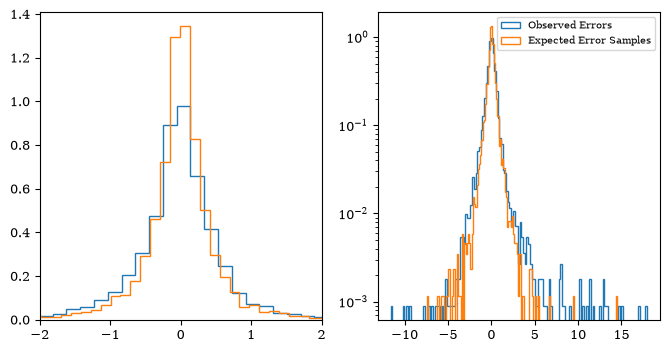

In [14]:
fig, ax = plt.subplots(figsize=(8, 4), ncols=2)
hist_kwargs = {"bins": "auto", "histtype": "step", "density": True}

za_cutoff = 86.

for ax_ob in ax:
    ax_ob.hist(errors[za_rad < np.deg2rad(za_cutoff)], label="Observed Errors", **hist_kwargs)
    ax_ob.hist(sl_samps, label="Expected Error Samples", **hist_kwargs)
ax[1].set_yscale("log")
ax[1].legend(fontsize="x-small")
ax[0].set_xlim([-2, 2])

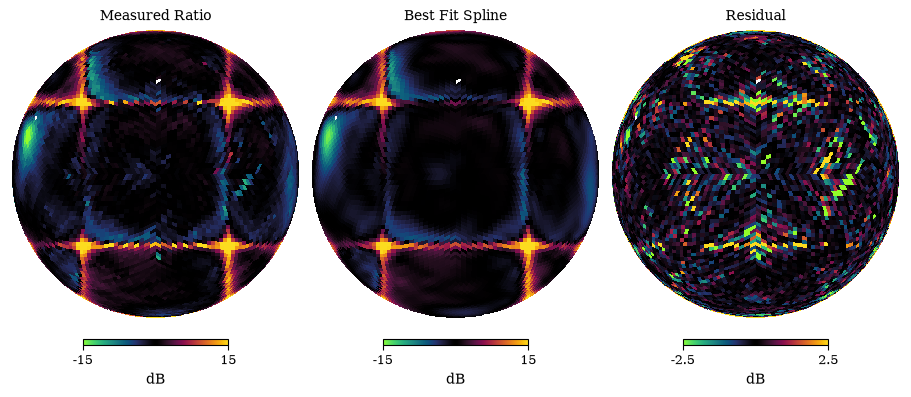

In [15]:
nside = 32
npix = hp.nside2npix(nside)
res_vmax = 15

_, _, above_horizon = get_above_horizon(nside)
count_map_gt_2 = count_map > 2
inds_kept = np.logical_and(above_horizon, count_map_gt_2)

orthview_kwargs = {
    "rot": (0, 90, 180),
    "half_sky": True,
    "badcolor": "white"
}

fill_map = partial(fill_map, npix=npix, inds_kept=inds_kept)

def fix_cmap_for_background(cmap_name):
    cmap = copy.deepcopy(getattr(cmr, cmap_name))
    cmap.set_bad("white")
    cmap.set_under("white")

    return cmap

fig = plt.figure(figsize=(9, 4))

res_for_plot = fill_map(res)

cmap = cmr.wildfire

hp.orthview(
    res_for_plot,
    cmap=cmap,
    min=-res_vmax,
    max=res_vmax,
    sub=(1, 3, 1),
    title="Measured Ratio",
    **orthview_kwargs
)

cb_ax = fig.axes[-1]
cb_ax.set_xlabel("dB")

mod_for_plot = fill_map(mod_for_data)

hp.orthview(
    mod_for_plot,
    cmap=cmap,
    min=-res_vmax,
    max=res_vmax,
    sub=(1, 3, 2),
    title="Best Fit Spline",
    **orthview_kwargs
)

cb_ax = fig.axes[-1]
cb_ax.set_xlabel("dB")

errors_for_plot = fill_map(errors)
hp.orthview(
    errors_for_plot,
    cmap=cmap,
    min=-2.5,
    max=2.5,
    sub=(1, 3, 3),
    title="Residual",
    **orthview_kwargs
)

cb_ax = fig.axes[-1]
cb_ax.set_xlabel("dB")

fig.savefig(f"{paper_plot_dir}/spline_example.pdf", bbox_inches="tight")

In [16]:
beam.feed_angle
beam.feed_array

array(['x', 'y'], dtype='<U1')

In [17]:
scatter_samps = jax.vmap(lambda x: scatter_coeffs(x, knot_mask, knot_ij))
samps_for_data = jnp.array(coeffs.posterior["surf_vals"]).reshape(16000, -1)
samps_for_data = scatter_samps(samps_for_data)

spl_samps = SphericalSpline(t_x, t_y, samps_for_data, p, q)
mod_samps = eval_spline_samples(spl_samps, dat_coord_1, dat_coord_2)



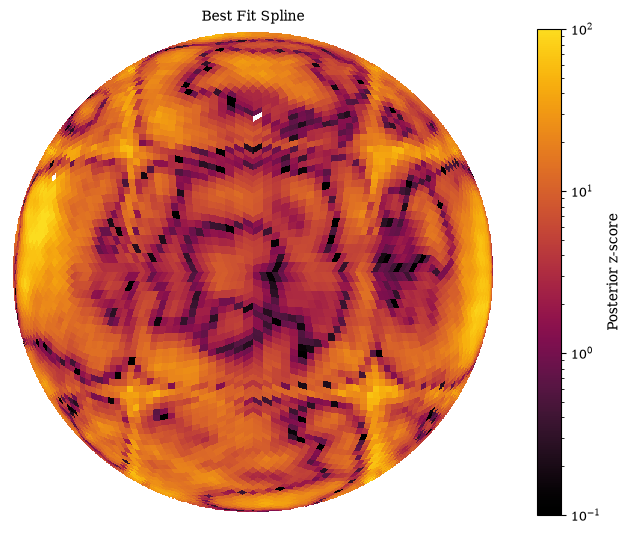

In [18]:
clip_val = 1e-1 # for plotting purposes because healpy is dumb

mean_mod = mod_samps.mean(axis=0)
std_mod = mod_samps.std(axis=0)

z_mod = np.abs(mean_mod / std_mod)
z_mod = np.clip(z_mod, a_min=clip_val, a_max=None)
z_mod_for_plot = fill_map(z_mod)

zmax = 100

hp.orthview(
    z_mod_for_plot,
    cmap=wildfire_top,
    max=zmax,
    title="Best Fit Spline",
    norm=LogNorm(vmin=clip_val, vmax=100),
    cbar = False,
    **orthview_kwargs
)

fig = plt.gcf()
ax = plt.gca()
z_im = ax.get_images()[0]

cbar = fig.colorbar(z_im, ax=ax, label="Posterior z-score")


In [19]:
sl_noise = dist.SoftLaplace(
    loc=0, 
    scale=noise_scale * 2 / np.pi
)
Nsamps = np.prod(coeffs.posterior["surf_vals"].shape[:2])
sl_noise_samps = sl.sample(jax.random.key(14616523), sample_shape=(16000,))

ppd_samps = mod_samps + sl_noise_samps
quants = (res >= ppd_samps).sum(axis=0) / Nsamps

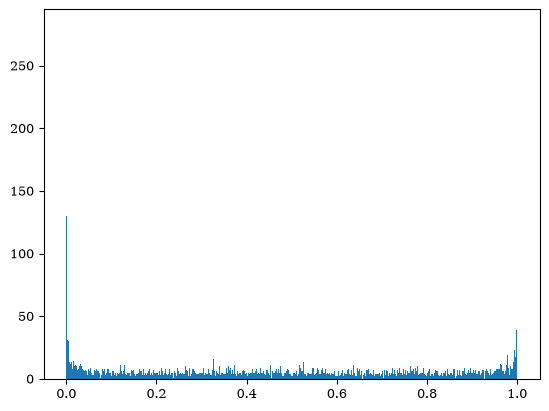

In [20]:

plt.hist(quants, bins=1000);

In [21]:
print(orthview_kwargs)

{'rot': (0, 90, 180), 'half_sky': True, 'badcolor': 'white'}


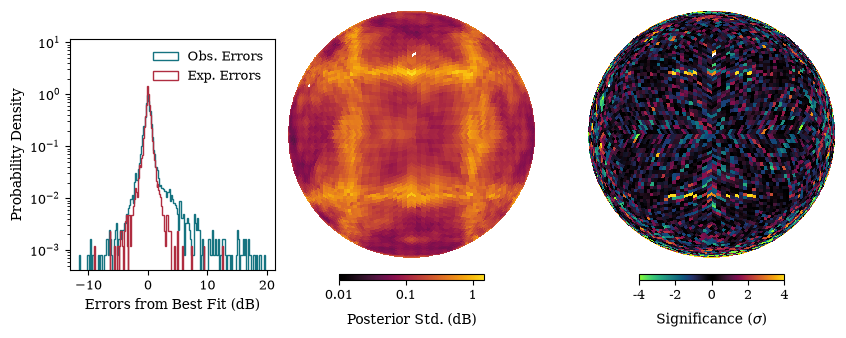

In [22]:
from scipy.stats import norm

clip_val = 4 # For plotting

ppz_map = fill_map(norm.ppf(quants))
wh_unseen = np.where(ppz_map == hp.UNSEEN)
ppz_map = np.clip(ppz_map, a_min=-clip_val, a_max=clip_val)
ppz_map[wh_unseen] = hp.UNSEEN

std_map = fill_map(std_mod)


sl = dist.SoftLaplace(
    loc=0, 
    scale=noise_scale * 2 / jnp.pi
)
exp_errors = sl.sample(jax.random.key(2367467))

fig = plt.figure(figsize=(9, 3))

ax0 = fig.add_subplot(1, 3, 1)
error_counts, _, _ = ax0.hist(errors, label="Obs. Errors", color=cmr.wildfire(0.25), **hist_kwargs)
exp_counts, _, _ = ax0.hist(exp_errors, label="Exp. Errors", color=cmr.wildfire(0.75), **hist_kwargs)
ax0.legend(frameon=False)
ax0.set_yscale("log")
ax0.set_xlabel("Errors from Best Fit (dB)")
ax0.set_ylabel("Probability Density")

all_counts = np.concatenate([error_counts, exp_counts])
min_counts = np.amin(all_counts[all_counts > 0])
max_counts = np.amax(all_counts)

ax0.set_ylim([0.5 * min_counts, 8 * max_counts])

hp.orthview(
    std_map,
    fig=fig.number,
    sub=(1, 3, 2),
    cmap=wildfire_top,
    min=1e-2,
    max=1.5,
    norm="log",
    title=None,
    **orthview_kwargs
)
cb_ax = fig.axes[-1]
cb_ax.set_xlabel("Posterior Std. (dB)", labelpad=8)
cb_ax.set_xticks([1e-2, 1e-1, 1])

hp.orthview(
    ppz_map,
    fig=fig.number,
    sub=(1, 3, 3),
    cmap=cmap,
    min=-clip_val,
    max=clip_val,
    title=None,
    **orthview_kwargs
)
cb_ax = fig.axes[-1]
cb_ax.set_xlabel(r"Significance ($\sigma$)", labelpad=8)
cb_ax.set_xticks([-4, -2, 0, 2, 4])

fig.savefig(f"{paper_plot_dir}/error_triplot.pdf", bbox_inches="tight")

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


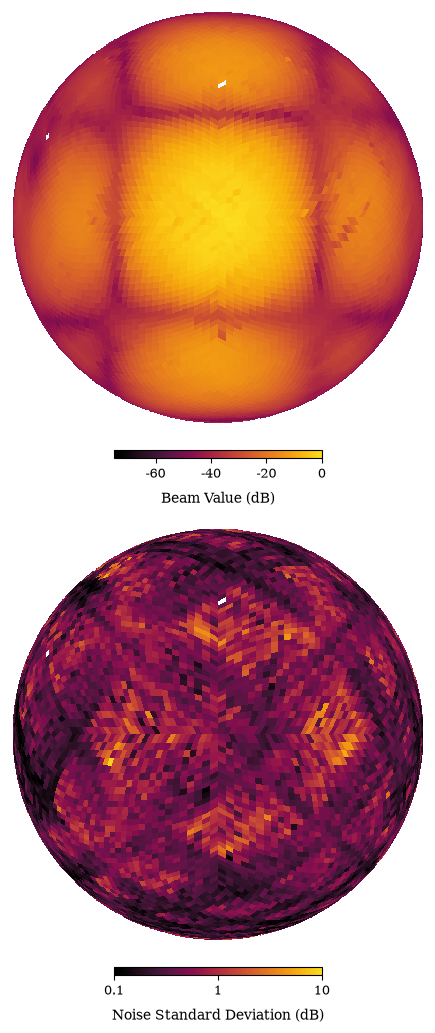

In [23]:
fig = plt.figure(figsize=[4.2, 8/3.25 * 4.2])

med_map = fill_map(median_values)
hp.orthview(
    med_map,
    fig=fig,
    sub=(2,1,1),
    cmap=wildfire_top,
    title=None,
    max=0,
    min=-75,
    **orthview_kwargs
)

cb_ax = fig.axes[-1]
cb_ax.set_xlabel(r"Beam Value (dB)", labelpad=8, fontsize=10)
cb_ax.set_xticks(range(-60, 20, 20))

noise_map = fill_map(noise_scale)
hp.orthview(
    noise_map,
    fig=fig,
    sub=(2, 1, 2),
    cmap=wildfire_top,
    norm="log",
    title=None,
    min=1e-1,
    max=10,
    **orthview_kwargs
)

cb_ax = fig.axes[-1]
cb_ax.set_xlabel(r"Noise Standard Deviation (dB)", labelpad=8, fontsize=10)
cb_ax.set_xticks([1e-1, 1, 10])
fig.tight_layout()
fig.savefig(f"{paper_plot_dir}/noise_map.pdf", bbox_inches="tight")

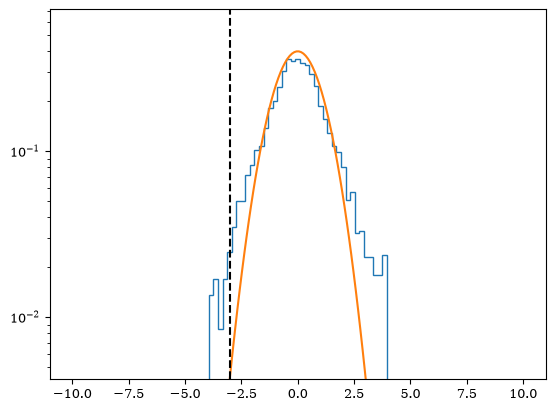

In [24]:

ppz_map = fill_map(norm.ppf(quants))
counts, _, _ = plt.hist(ppz_map, log=True, bins=np.linspace(-10, 10, num=100), density=True, histtype="step")
xplot = np.linspace(-5, 5, num=100)
plt.plot(xplot, norm.pdf(xplot))
plt.ylim([0.5 * np.amin(counts[counts > 0]), 2 * np.amax(counts)])
plt.axvline(-3, color="black", linestyle="--");

In [24]:
def healpix_ew_ns_slices(
    hp_map,
    nside=None,
    za_max=90.0,
    rotate=True,
    rotation_angle=np.pi / 4,
    return_indices=False,
):
    """Return EW and NS slices through a HEALPix beam map.

    Parameters
    ----------
    hp_map : array-like
        Full-sky HEALPix map.
    nside : int, optional
        HEALPix NSIDE. If None, inferred from hp_map.
    za_max : float
        Maximum zenith angle in degrees.
    rotate : bool
        If True, rotate the map by +pi/4 before slicing. This is useful because
        NSIDE=32 maps have pixels along diagonal axes rather than cardinal axes.
    rotation_angle : float
        Rotation angle in radians.
    return_indices : bool
        If True, also return HEALPix pixel indices used for the slices.

    Returns
    -------
    slices : dict
        Dictionary with keys ``"EW"`` and ``"NS"``. Each contains
        ``(signed_za_deg, values)`` by default.

        Sign convention:
        - NS slice: negative = north, positive = south
        - EW slice: negative = east, positive = west
    """
    hp_map = np.asarray(hp_map)

    if nside is None:
        nside = hp.npix2nside(len(hp_map))

    npix = hp.nside2npix(nside)
    if len(hp_map) != npix:
        raise ValueError(
            f"Map has length {len(hp_map)}, expected {npix} for NSIDE={nside}."
        )

    if rotate:
        pix = np.arange(npix)
        theta, phi = hp.pix2ang(nside, pix)
        rotated_pix = hp.ang2pix(nside, theta, phi + rotation_angle)
        work_map = hp_map[rotated_pix]
    else:
        work_map = hp_map

    pix = np.arange(npix)
    theta, phi = hp.pix2ang(nside, pix)

    za_deg = np.degrees(theta)
    phi_deg = np.mod(np.degrees(phi), 360.0)
    phi_round = np.round(phi_deg).astype(int) % 360

    above = za_deg <= za_max

    # After +pi/4 rotation, the diagonal HEALPix pixel tracks correspond
    # to the desired cardinal slices.
    ns_mask = above & np.isin(phi_round, [45, 225])
    ew_mask = above & np.isin(phi_round, [135, 315])

    ns_idx = pix[ns_mask]
    ew_idx = pix[ew_mask]

    def signed_slice(indices):
        theta_i, phi_i = hp.pix2ang(nside, indices)
        za_i = np.degrees(theta_i)
        phi_i = np.mod(np.degrees(phi_i), 360.0)

        signed_za = np.where(phi_i <= 180.0, -za_i, za_i)
        values = work_map[indices]

        order = np.argsort(signed_za)
        return signed_za[order], values[order], indices[order]

    ns_za, ns_values, ns_idx = signed_slice(ns_idx)
    ew_za, ew_values, ew_idx = signed_slice(ew_idx)

    if return_indices:
        return {
            "EW": (ew_za, ew_values, ew_idx),
            "NS": (ns_za, ns_values, ns_idx),
        }

    return {
        "EW": (ew_za, ew_values),
        "NS": (ns_za, ns_values),
    }

invalid value encountered in log10


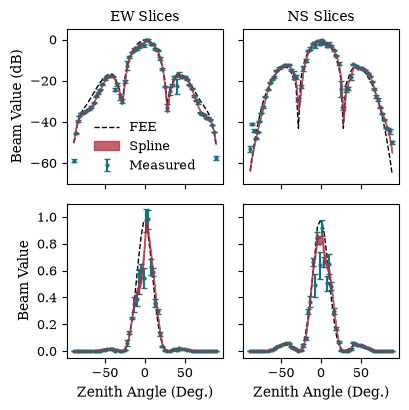

In [34]:
figlen = 4.2
fig, ax = plt.subplots(
    figsize=(figlen, figlen),
    nrows=2,
    ncols=2,
    sharex=True,
)

def to_lin(db):
    return 10**(db / 10)

rotation_angle = -np.pi/4

FEE_map = fill_map(model_beam)
spline_beam_samples = mod_samps + to_db(model_beam)

def replace_unseen(slices, direction):
    unseen = slices[direction][1] == hp.UNSEEN
    slices[direction][1][unseen] = np.nan

    return

for lin_ind, lin in enumerate([False, True]):
    if lin:
        FEE_for_slices = FEE_map
        
        linear_dat_samples = to_lin(sl_noise_samps + median_values)

        mean_dat = fill_map(linear_dat_samples.mean(axis=0))
        quants_dat = np.quantile(linear_dat_samples, norm.cdf([-1, 1]), axis=0)

        dat_err_low = mean_dat - fill_map(quants_dat[0])
        dat_err_high = fill_map(quants_dat[1]) - mean_dat
       

        linear_spline_beam_samples = to_lin(spline_beam_samples)
        spline_beam_quants = np.quantile(
            linear_spline_beam_samples, 
            norm.cdf([-1, 1]),
            axis=0
        )
    else:
        FEE_for_slices = to_db(FEE_map)
        mean_dat = fill_map(median_values)
        # symmetric
        dat_err_low = fill_map(noise_scale)
        dat_err_high = fill_map(noise_scale)

        spline_beam_quants = np.quantile(
            spline_beam_samples, 
            norm.cdf([-1, 1]), 
            axis=0
        )


    FEE_slices = healpix_ew_ns_slices(
        FEE_for_slices,
        rotation_angle=rotation_angle
    )

    dat_slices = healpix_ew_ns_slices(
        mean_dat,
        rotation_angle=rotation_angle
    )
    dat_err_low_slices = healpix_ew_ns_slices(
        dat_err_low,
        rotation_angle=rotation_angle
    )
    dat_err_high_slices = healpix_ew_ns_slices(
            dat_err_high,
            rotation_angle=rotation_angle
        )

    spline_beam_low_slices = healpix_ew_ns_slices(
        fill_map(spline_beam_quants[0]),
        rotation_angle=rotation_angle
    )
    spline_beam_high_slices = healpix_ew_ns_slices(
        fill_map(spline_beam_quants[1]),
        rotation_angle=rotation_angle
    )

    for dir_ind, direction in enumerate(["EW", "NS"]):
        ax_ob = ax[lin_ind, dir_ind]
        if lin:
            ax_ob.set_ylim([-0.05, 1.05])
            if dir_ind:
                ax_ob.set_yticklabels([])
        else:
            ax_ob.set_ylim([-70, 5])
            if dir_ind:
                ax_ob.set_yticklabels([])

        # Minus signs so it's West->East, South->North
        for slices in [
            dat_slices, 
            dat_err_low_slices, 
            dat_err_high_slices, 
            spline_beam_low_slices, 
            spline_beam_high_slices,
            FEE_slices
        ]:
            replace_unseen(slices, direction)
        ax_ob.plot(
            -FEE_slices[direction][0],
            FEE_slices[direction][1],
            color=cmr.wildfire(0.5),
            linestyle="--",
            label="FEE",
            lw=1,
            zorder=1
        )


        ax_ob.errorbar(
            -dat_slices[direction][0],
            dat_slices[direction][1],
            yerr=[
                dat_err_low_slices[direction][1],
                dat_err_high_slices[direction][1],
            ],
            color=cmr.wildfire(0.25),
            linestyle="none",
            marker=".",
            label="Measured",
            capsize=2,
            markersize=4,
            zorder=2,
        )
        ax_ob.fill_between(
            -spline_beam_low_slices[direction][0],
            spline_beam_low_slices[direction][1],
            spline_beam_high_slices[direction][1],
            color=cmr.wildfire(0.75),
            alpha=0.75,
            label="Spline",
            zorder=3
        )
        if not dir_ind:
            if lin_ind:
                ax_ob.set_ylabel("Beam Value")
            else:
                ax_ob.set_ylabel("Beam Value (dB)")
        if lin_ind:
            ax_ob.set_xlabel("Zenith Angle (Deg.)")
            ax_ob.set_ylim([-0.05, 1.1])
        else:
            ax_ob.set_title(f"{direction} Slices")
ax[0, 0].legend(frameon=False)
fig.tight_layout()

fig.savefig(f"{paper_plot_dir}/spline_slice_plot.pdf")

Look at swapped pols as a sanity check

The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.


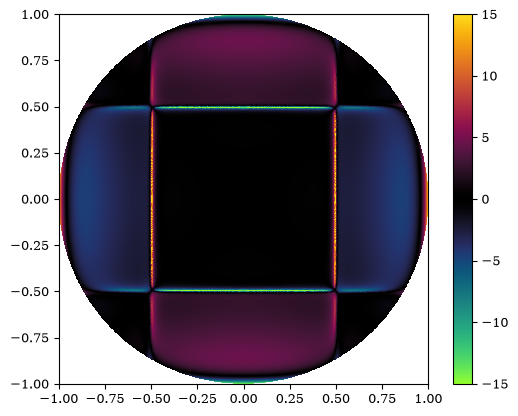

In [77]:
fig, ax = plt.subplots()

im = ax.pcolormesh(
    xbeam, 
    ybeam, 
    to_db(beam.data_array[0, 0, 0].real) - to_db(beam.data_array[0, 1, 0].real), 
    cmap=cmr.wildfire,
    vmax=15,
    vmin=-15,
    rasterized=True
)
ax.set_aspect("equal")
plt.colorbar(im)

In [30]:


t_x, t_y, p, q, n_x, n_y, _= prep_spline_params(beam, ortho_knots=True, spice_variant=0)
knot_mask = make_disk_mask(t_x, t_y, p, q)           # (n_x, n_y) bool, numpy
knot_ij, Nparam = make_flat_index(knot_mask)            # static arrays

params_filepath = f"{indir}/svi_params_nonuniform_knots.pkl"

with open(params_filepath, "rb") as params_file:
    params = pickle.load(params_file)
coeffs_to_use = params["surf_vals_auto_loc"]
coeffs_to_use = scatter_coeffs(
    coeffs_to_use,
    knot_mask, 
    knot_ij
)
print(coeffs_to_use.shape)
spl = SphericalSpline(t_x, t_y, coeffs_to_use, p, q)
mod_for_data = eval_spline_batch(spl, dat_coord_1, dat_coord_2)
errors = res - mod_for_data

loglike = sl_noise.log_prob(errors).sum()
BIC = Nparam * np.log(len(errors)) - 2 * loglike 
print(loglike, BIC)

(41, 41)
-10945.363 34722.684


In [31]:
# spicy_1: Twice as dense
# spicy_2: Twice as dense except near horizon
# spicy_3: Twice as dense except in main lobe
# spicy_4: Twice as dense only at horizon
# spicy_5: quad density at horizon
# spicy_6: octo density at horizon
# spicy_4 ~ spicy_5 < spicy_3 < vanilla ~ spicy < spicy_2 < spicy_6 (Only increase density at horizon)

spice_levels = [BIC, ]
for spice_variant in range(1, 7):
    t_x, t_y, p, q, n_x, n_y, _= prep_spline_params(beam, ortho_knots=True, 
                                                    spice_variant=spice_variant)
    knot_mask = make_disk_mask(t_x, t_y, p, q)           # (n_x, n_y) bool, numpy
    knot_ij, Nparam = make_flat_index(knot_mask)            # static arrays

    params_filepath = f"{indir}/svi_params_spicy_knots_{spice_variant}.pkl"

    with open(params_filepath, "rb") as params_file:
        params = pickle.load(params_file)
    coeffs_to_use = params["surf_vals_auto_loc"]
    coeffs_to_use = scatter_coeffs(
        coeffs_to_use,
        knot_mask, 
        knot_ij
    )
    spl = SphericalSpline(t_x, t_y, coeffs_to_use, p, q)
    mod_for_data = eval_spline_batch(spl, dat_coord_1, dat_coord_2)
    errors = res - mod_for_data

    loglike = sl_noise.log_prob(errors).sum()
    BIC = Nparam * np.log(len(errors)) - 2 * loglike 
    spice_levels.append(BIC)

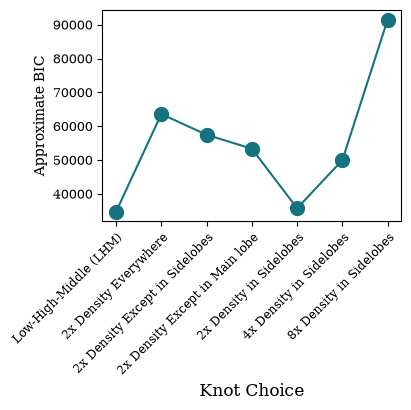

In [32]:
fig, ax = plt.subplots(figsize=(4.2, 4.2))
ax.plot(spice_levels, marker=".", markersize=20, color=cmr.wildfire(0.25))
ax.set_ylabel("Approximate BIC")
ax.set_xlabel("Knot Choice", fontsize="large")

xticklabels = [
    "Low-High-Middle (LHM)",
    "2x Density Everywhere",
    "2x Density Except in Sidelobes",
    "2x Density Except in Main lobe",
    "2x Density in Sidelobes",
    "4x Density in Sidelobes",
    "8x Density in Sidelobes"
]
ax.set_xticks(np.arange(7))
ax.set_xticklabels(xticklabels, rotation=45, ha="right", rotation_mode="anchor",
                   fontsize="small")
fig.tight_layout()
fig.savefig(f"{paper_plot_dir}/spline_BIC.pdf", bbox_inches="tight")